# ISMIP-HOM D, Weertman Sliding

## Part 1: Single-layer SSA 

In [1]:
###importing packages 
import numpy as np
import math
import matplotlib.pyplot as plt
import firedrake
from firedrake import (
    Constant, Function, inner, sym, grad, avg, jump,
    sin, dx, dS, FacetNormal, derivative,
    NonlinearVariationalProblem, NonlinearVariationalSolver,
)
from icepack2.model.minimization import viscous_power
from icepack2.constants import ice_density as ρ_I, gravity as g, glen_flow_law
from multilayer.model.minimization import basal_stress_power, interlayer_power, friction_power
from multilayer.model.utilities import (
    create_function_space, split_fields, layer_thicknesses,
)

In [2]:
###creating the domain + constants 
Lx = 80e3
nx = 40 
omega = Constant(2*np.pi/Lx) 
alpha = math.radians(0.1) #slope 
tan_alpha = math.tan(alpha)

mesh = firedrake.PeriodicRectangleMesh(nx, nx, Lx, Lx) 
x, y = firedrake.SpatialCoordinate(mesh) 

Q = firedrake.FunctionSpace(mesh, 'CG', 1) 

h_total = Function(Q).interpolate(Constant(1000.0)) #ice thickness
C_friction = Function(Q).interpolate((Constant(1000.0) + Constant(1000.0)*sin(omega*x))*Constant(1e-6))
                                     #friction coeff from Pattyn et al 2008 
K_friction = Constant(1.0)/(C_friction + Constant(1e-10)) #friction coeff in icepack units 

In [3]:
###model set up 
L = 1 #number of layers
h_layers = layer_thicknesses(h_total, L) 

#layer function space
Z = create_function_space(mesh, L) 
z = Function(Z)
fields = split_fields(firedrake.split(z), L) 
ν = FacetNormal(mesh)
s_zero = Function(Q).assign(0.0)

#action functional
Lag1 = Constant(0)*dx(mesh) 

In [4]:
###rheology and solve params 
A = Constant(100.0) #fMPa; Pattyn et al 2008
n = Constant(glen_flow_law) #3
m = Constant(1.0) #sliding exponent 

sparams = {
    'snes_type': 'newtonls', 
    'snes_max_it': 200, 
    'snes_linesearch_type': 'bt', 
    'snes_divergence_tolerance': -1, 
    'ksp_type': 'preonly', 
    'pc_type': 'lu', 
    'pc_factor_mat_solver_type': 'mumps', 
}

#rheology = {'flow_law_coefficient': A, 'flow_law_exponent': n} 

#need solve with contination for velocity to plot 
def solve_with_continuation(solver, n_const, target_n, num_steps=5): 
    '''Ramp the Glen exponent from 1 to target_n.'''
    for exponent in np.linspace(1.0, target_n, num_steps): 
        n_const.assign(exponent)
        solver.solve()

In [5]:
###Creating the model 
fl = fields[0]
u_l, M_l, S_below = fl['velocity'], fl['membrane_stress'], fl['interlayer_stress'] 
h_l = h_layers[0]

#viscous power 
Lag1 += viscous_power(
    membrane_stress=M_l, thickness=h_l, 
    flow_law_coefficient=A, flow_law_exponent=n, 
) 

#momentum balance
ε_u = sym(grad(u_l))
Lag1 += -h_l*inner(M_l, ε_u)*dx #membrane stress
Lag1 += -inner(S_below, u_l)*dx #basal traction 
Lag1 += ρ_I*g*h_l*Constant(tan_alpha)*u_l[0]*dx #driving stress

#basal friction power (weertman) 
Lag1 += friction_power(
    basal_stress=fields[0] ['interlayer_stress'], 
    sliding_coefficient=K_friction, 
    sliding_exponent=m
) 

#interlayer stress power <-- 

In [6]:
###creating the problem + solver 
F = derivative(Lag1, z)
bcs = [firedrake.DirichletBC(Z.sub(0).sub(1), 0, (1, 2))]

problem = NonlinearVariationalProblem(
    F, z, bcs, form_compiler_parameters={'quadrature_degree':8}
)

solver = NonlinearVariationalSolver(problem, solver_parameters=sparams) 
solve_with_continuation(solver, n, glen_flow_law)
u_ssa = z.subfunctions[0]

firedrake:WARNING Subdomain (1, 2) is empty. This is likely an error. Did you choose the right label?


In [7]:
###set up to extract velocity profile 
n_sample = 101
x_hat = np.linspace(0, 1, n_sample)
y_mid = Lx/2

def extract_profile(u_func): 
    return np.array([u_func.at([xi*Lx, y_mid])[0] for xi in x_hat])

/Users/brooklynwright/venv-firedrake/lib/python3.14/site-packages/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/Users/brooklynwright/venv-firedrake/lib/python3.14/site-packages/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


Text(0.5, 0.98, 'ISMIP-HOM D, L = 80 km, Weertman Sliding')

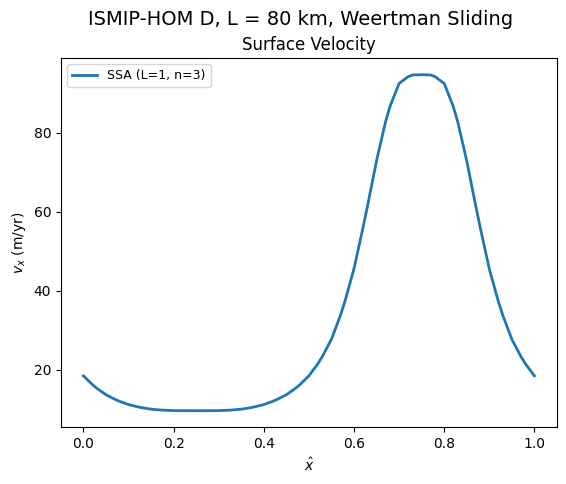

In [8]:
###extracting velocity profile + plotting 
profile_ssa = extract_profile(u_ssa) 

fig, axes = plt.subplots()
plt.plot(x_hat, profile_ssa, 'C0-', lw=2, label='SSA (L=1, n=3)')
axes.set_xlabel(r'$\hat{x}$')
axes.set_ylabel(r'$v_x$ (m/yr)')
axes.set_title('Surface Velocity') 
axes.legend(fontsize=9)
fig.suptitle(f"ISMIP-HOM D, L = {Lx/1e3:.0f} km, Weertman Sliding", fontsize=14)

## Part 2: Two-layer Uniform Rheology 

In [9]:
L2 = 2
h_layers2 = layer_thicknesses(h_total, L2) 

n2 = Constant(glen_flow_law)

Z2 = create_function_space(mesh, L2) 
z2 = Function(Z2)
fields2 = split_fields(firedrake.split(z2), L2) 

Lag2 = Constant(0)*dx(mesh) 

In [10]:
###creating the model 
for l in range(L2): 
    h_l = h_layers2[l]
    fl = fields2[l]
    u_l, M_l = fl['velocity'], fl['membrane_stress']
    S_below = fl['interlayer_stress'] 
    S_above = fields2[l+1]['interlayer_stress'] if l < L2 - 1 else None

    Lag2 += viscous_power(membrane_stress=M_l, thickness=h_l, flow_law_coefficient=A, flow_law_exponent=n2)

    ε_u = sym(grad(u_l))
    Lag2 += -h_l*inner(M_l, ε_u)*dx #membrane stress
    Lag2 += -inner(S_below, u_l)*dx #basal stress? 
    if S_above is not None: 
        Lag2 += inner(S_above, u_l)*dx
    Lag2 += ρ_I*g*h_l*Constant(tan_alpha)*u_l[0]*dx

#basal friction power
Lag2 += friction_power(
    basal_stress=fields2[0]['interlayer_stress'], 
    sliding_coefficient=K_friction, 
    sliding_exponent=m, 
)

#interlayer stress power 
Lag2 += interlayer_power(
    interlayer_stress=fields2[1]['interlayer_stress'], 
    thickness_above=h_layers2[1], thickness_below=h_layers2[0], 
    flow_law_coefficient=A, flow_law_exponent=n2
)

In [11]:
###solver 
F2 = derivative(Lag2, z2)
bcs2=[
    firedrake.DirichletBC(Z2.sub(0).sub(1), 0, (1, 2)), 
    firedrake.DirichletBC(Z2.sub(3).sub(1), 0, (1, 2)), 
]

problem2 = NonlinearVariationalProblem(
    F2, z2, bcs2, form_compiler_parameters={'quadrature_degree':8} 
)

solver2 = NonlinearVariationalSolver(problem2, solver_parameters=sparams) 
solve_with_continuation(solver2, n2, glen_flow_law)
u_bottom = z2.subfunctions[0]
u_top = z2.subfunctions[3]

firedrake:WARNING Subdomain (1, 2) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (1, 2) is empty. This is likely an error. Did you choose the right label?


/Users/brooklynwright/venv-firedrake/lib/python3.14/site-packages/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/Users/brooklynwright/venv-firedrake/lib/python3.14/site-packages/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


Text(0.5, 0.98, 'ISMIP-HOM D, L = 80 km, Weertman Sliding')

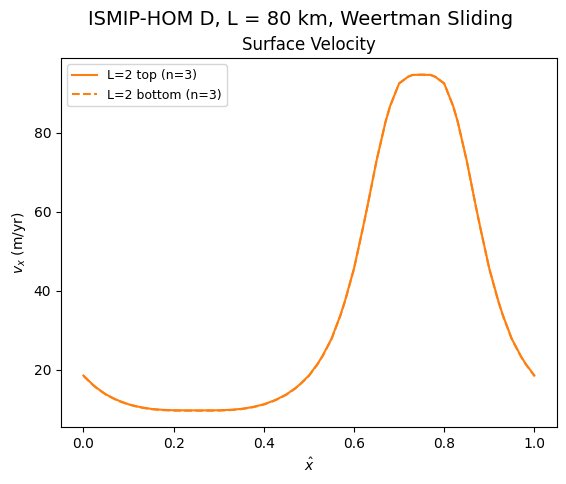

In [12]:
#extract profile + plot
profile_top = extract_profile(u_top)
profile_bot = extract_profile(u_bottom) 

fig, axes = plt.subplots()
plt.plot(x_hat, profile_top, 'C1-', label='L=2 top (n=3)')
plt.plot(x_hat, profile_bot, 'C1--', label='L=2 bottom (n=3)')
axes.set_xlabel(r'$\hat{x}$')
axes.set_ylabel(r'$v_x$ (m/yr)')
axes.set_title('Surface Velocity') 
axes.legend(fontsize=9)
fig.suptitle(f"ISMIP-HOM D, L = {Lx/1e3:.0f} km, Weertman Sliding", fontsize=14)

## Part 3: Two-layer Rheology

In [13]:
###setting up for model 
fractions = [0.15, 0.85] #basal ice, stratigraphic ice 
n_bot_target, n_top_target = 4.0, 1.8
A_bot_target, A_top_target = 1000.0, 6.3

h_layersc = layer_thicknesses(h_total, 2, fractions=fractions) 

#constants
n_bot = Constant(glen_flow_law)
n_top = Constant(glen_flow_law) 
A_bot = Constant(100.0)
A_top = Constant(100.0) 

Zc = create_function_space(mesh, 2)
zc = Function(Zc)
fc = split_fields(firedrake.split(zc), 2)

#action functional 
Lagc = Constant(0)*dx(mesh)

#more model set up <-- for layers
for l, (h_l, n_l, A_l) in enumerate(
    zip(h_layersc, [n_bot, n_top], [A_bot, A_top])
): 
    fl=fc[l]
    u_l, M_l = fl['velocity'], fl['membrane_stress']
    S_below = fl['interlayer_stress'] 
    S_above = fc[l+1]['interlayer_stress'] if l<1 else None

    Lagc += viscous_power(membrane_stress=M_l, thickness=h_l,
        flow_law_coefficient=A_l, flow_law_exponent=n_l,
    )

    ε_u = sym(grad(u_l))
    Lagc += -h_l*inner(M_l, ε_u)*dx
    Lagc += -inner(S_below, u_l)*dx
    if S_above is not None: 
        Lagc += inner(S_above, u_l)*dx
    Lagc += ρ_I*g*h_l*Constant(tan_alpha)*u_l[0]*dx

Lagc += friction_power(
    basal_stress=fc[0]['interlayer_stress'], 
    sliding_coefficient=K_friction, 
    sliding_exponent=m, 
)

Lagc += interlayer_power(interlayer_stress=fc[1]["interlayer_stress"], thickness_above=h_layersc[1], thickness_below=h_layersc[0], flow_law_coefficient=A_bot, flow_law_exponent=n_bot)


In [14]:
###solver 
Fc = derivative(Lagc, zc)
bcs_c = [
    firedrake.DirichletBC(Zc.sub(0).sub(1), 0, (1, 2)), 
    firedrake.DirichletBC(Zc.sub(3).sub(1), 0, (1, 2))
] 

problemc = NonlinearVariationalProblem(
    Fc, zc, bcs_c, form_compiler_parameters={'quadrature_degree':8}
)

solverc = NonlinearVariationalSolver(problemc, solver_parameters=sparams) 

#ramp n and A from uniform to composite
A_start = 100.0
for λ in np.linspace(0.0, 1.0, 10): 
    n_bot.assign((1 - λ) + λ * n_bot_target)
    n_top.assign((1 - λ) + λ * n_top_target)
    A_bot.assign(np.exp((1 - λ) * np.log(A_start) + λ * np.log(A_bot_target)))
    A_top.assign(np.exp((1 - λ) * np.log(A_start) + λ * np.log(A_top_target)))
    solverc.solve()

u_c_bot = zc.subfunctions[0]
u_c_top = zc.subfunctions[3]

firedrake:WARNING Subdomain (1, 2) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (1, 2) is empty. This is likely an error. Did you choose the right label?


/Users/brooklynwright/venv-firedrake/lib/python3.14/site-packages/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/Users/brooklynwright/venv-firedrake/lib/python3.14/site-packages/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


Text(0.5, 0.98, 'ISMIP-HOM D, L = 80 km, Weertman Sliding')

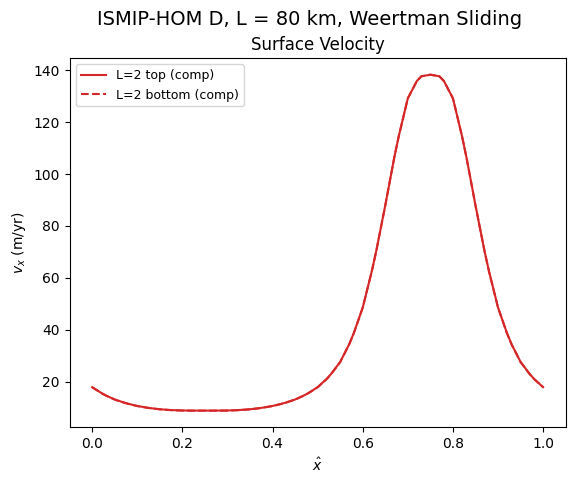

In [15]:
###extract profiles and plot 
profile_c_top = extract_profile(u_c_top)
profile_c_bot = extract_profile(u_c_bot)

fig, axes = plt.subplots()
plt.plot(x_hat, profile_c_top, 'C3-', label='L=2 top (comp)')
plt.plot(x_hat, profile_c_bot, 'C3--', label='L=2 bottom (comp)')
axes.set_xlabel(r'$\hat{x}$')
axes.set_ylabel(r'$v_x$ (m/yr)')
axes.set_title('Surface Velocity') 
axes.legend(fontsize=9)
fig.suptitle(f"ISMIP-HOM D, L = {Lx/1e3:.0f} km, Weertman Sliding", fontsize=14)

## Comparison

Text(0.5, 0.98, 'ISMIP-HOM D, L = 80 km, Weertman')

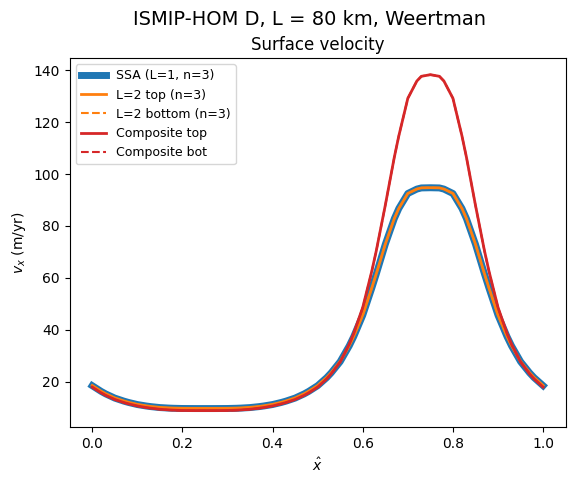

In [19]:
#plotting velocity all together 
fig, axes = plt.subplots()

axes.plot(x_hat, profile_ssa, 'C0-', lw=5, label='SSA (L=1, n=3)')
axes.plot(x_hat, profile_top, "C1-", lw=2, label="L=2 top (n=3)")
axes.plot(x_hat, profile_bot, "C1--", lw=1.5, label="L=2 bottom (n=3)")
axes.plot(x_hat, profile_c_top, "C3-", lw=2, label="Composite top")
axes.plot(x_hat, profile_c_bot, "C3--", lw=1.5, label="Composite bot")
axes.set_xlabel(r"$\hat{x}$")
axes.set_ylabel(r"$v_x$ (m/yr)")
axes.set_title("Surface velocity")
axes.legend(fontsize=9)
fig.suptitle(f"ISMIP-HOM D, L = {Lx/1e3:.0f} km, Weertman", fontsize=14)

Text(0.5, 0.98, 'ISMIP-HOM D, L = 80 km, Weertman')

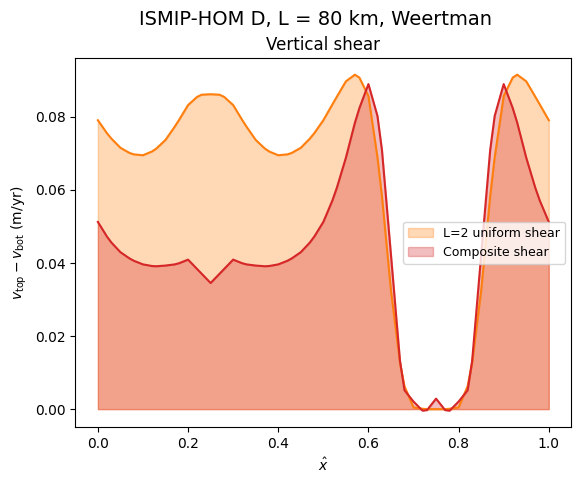

In [20]:
###plotting vertical shear 
fig, axes = plt.subplots()
axes.fill_between(x_hat, profile_top-profile_bot, alpha=0.3, color='C1', label='L=2 uniform shear') 
axes.fill_between(
    x_hat, profile_c_top-profile_c_bot, alpha=0.3, color='C3', label='Composite shear')
axes.plot(x_hat, profile_top - profile_bot, "C1-", lw=1.5)
axes.plot(x_hat, profile_c_top - profile_c_bot, "C3-", lw=1.5)
axes.set_xlabel(r"$\hat{x}$")
axes.set_ylabel(r"$v_{\mathrm{top}} - v_{\mathrm{bot}}$ (m/yr)")
axes.set_title("Vertical shear")
axes.legend(fontsize=9)
fig.suptitle(f"ISMIP-HOM D, L = {Lx/1e3:.0f} km, Weertman", fontsize=14)